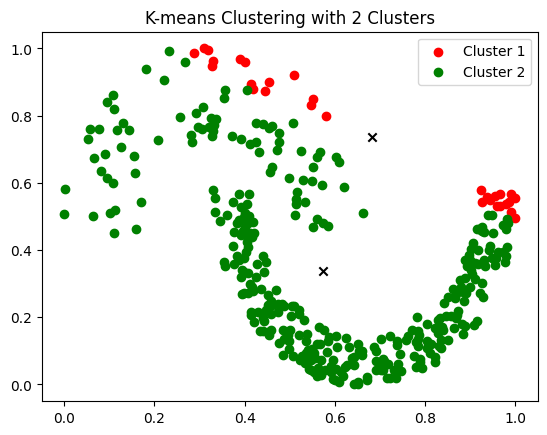

Number of Clusters: 2, Inertia: 43.54690551467469


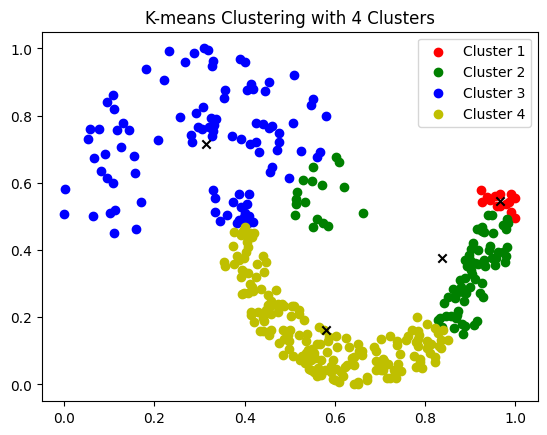

Number of Clusters: 4, Inertia: 13.641112605334651


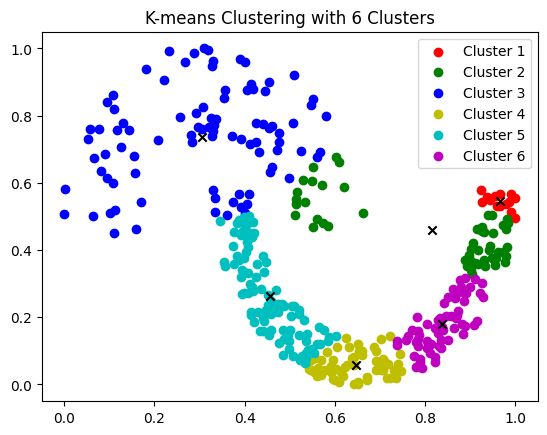

Number of Clusters: 6, Inertia: 8.646621058785321


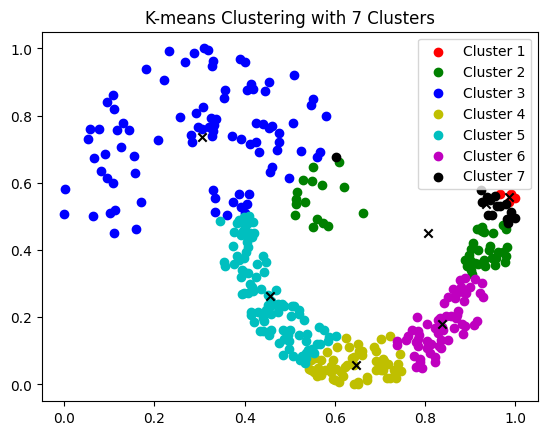

Number of Clusters: 7, Inertia: 8.596898337160958


In [3]:
import random
import math
import matplotlib.pyplot as plt

def load_points(file_path):
    points = []
    with open(file_path, 'r') as f:
        for line in f:
            x_coord, y_coord = map(float, line.strip().split())
            points.append([x_coord, y_coord])
    return points

def euclidean_distance(pt1, pt2):
    return math.sqrt((pt1[0] - pt2[0]) ** 2 + (pt1[1] - pt2[1]) ** 2)

# Function to perform K-means clustering
def k_means_clustering(points, num_clusters, seed_value, max_iterations=100, shift_threshold=50):

    random.seed(seed_value)  # Seed to ensure consistent results
    
    # Initialize cluster centers randomly from the data points
    cluster_centers = random.sample(points, num_clusters)
    
    # Placeholder for storing clusters
    groupings = [[] for _ in range(num_clusters)]
    
    for iteration in range(max_iterations):
        new_groupings = [[] for _ in range(num_clusters)]
        
        # Assign each point to the nearest cluster center
        for pt in points:
            distances = [euclidean_distance(pt, center) for center in cluster_centers]
            nearest_center_idx = distances.index(min(distances))
            new_groupings[nearest_center_idx].append(pt)
        
        total_shift = 0
        # Update each cluster center based on its points
        for i in range(num_clusters):
            previous_center = cluster_centers[i]
            if new_groupings[i]:
                new_center_x = sum(point[0] for point in new_groupings[i]) / len(new_groupings[i])
                new_center_y = sum(point[1] for point in new_groupings[i]) / len(new_groupings[i])
                cluster_centers[i] = [new_center_x, new_center_y]
                total_shift += euclidean_distance(previous_center, cluster_centers[i])
        
        groupings = new_groupings
        
        # If the total shift is below the threshold, stop the iterations
        if total_shift < shift_threshold:
            break
    
    return groupings, cluster_centers

# Function to display clusters and their centers
def display_clusters(groupings, cluster_centers, num_clusters):
    color_options = ['r', 'g', 'b', 'y', 'c', 'm', 'k']
    for i in range(num_clusters):
        cluster = groupings[i]
        x_vals, y_vals = zip(*cluster)
        plt.scatter(x_vals, y_vals, color=color_options[i % len(color_options)], label=f'Cluster {i + 1}')
        plt.scatter(cluster_centers[i][0], cluster_centers[i][1], color='black', marker='x')
    plt.title(f'K-means Clustering with {num_clusters} Clusters')
    plt.legend()
    plt.show()

# Function to calculate inertia (sum of squared distances)
def compute_inertia(groupings, cluster_centers):
    total_inertia = 0
    for i in range(len(groupings)):
        for pt in groupings[i]:
            total_inertia += euclidean_distance(pt, cluster_centers[i]) ** 2
    return total_inertia

def execute_clustering():
    data_file = 'jain_feats.txt'
    student_seed = 11213001
    points = load_points(data_file)
    
    for k in [2, 4, 6, 7]:
        clusters, centers = k_means_clustering(points, k, student_seed)
        display_clusters(clusters, centers, k)
        inertia = compute_inertia(clusters, centers)
        print(f'Number of Clusters: {k}, Inertia: {inertia}')

if __name__ == '__main__':
    execute_clustering()
